# Ch19 快速控制原型(Rapid Control Prototyping, RCP)

**對應原書**:Chapter 19(原書用商用 RCP 硬體;這裡用 **ESP32 + Python** 全開源重現)
**軟體替代**:商用 RCP 平台 → ESP32(即時迴路)+ Python(規劃/分析/調機),韌體見 `../../hardware/esp32/`

## RCP 工作流程
1. **記錄**:ESP32 以 100 Hz 執行迴路,經序列埠回傳 CSV 遙測。
2. **辨識**:對開迴路步階記錄擬合一階模型 $K/(\tau s+1)$。
3. **設計**:λ-tuning 算 PI 增益。
4. **驗證**:先在 Python 模擬確認,再下載到 ESP32 實測。
5. **等價性**:Python 的 `DiscretePID` 與韌體 C 程式碼**逐樣本比對**(host 端編譯測試見 hardware/esp32/test_host)。

## 遙測與命令協定(對應韌體)
- 遙測(115200 baud):`millis,target,actual,pwm`
- 命令:`SET,KP,2.0` / `SET,KI,1.0` / `SET,KD,0.05` / `SET,TARGET,500` / `STEP,100`(開迴路 PWM 步階)

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from common.control_helpers import (first_order, second_order, integrator, inertia,
                                    pi, pid, closed_loop, margins, step_metrics, bandwidth_hz)
from common.sim import (DiscretePID, MotorPlant, DCMotorPlant, TwoMassPlant,
                        Backlash, EncoderModel, Delay, saturate, quantize, coulomb)
from common.dsa import chirp_excitation, prbs_excitation, measure_frf, frf_of_system
from common.plots import bode_compare
np.set_printoptions(precision=4, suppress=True)

遙測前 5 行:
millis,target,actual,pwm
0,0.0,1.037,100.0
10,0.0,14.228,100.0
20,0.0,24.056,100.0
30,0.0,30.014,100.0

擬合:K=2.996(真值 3.0),tau=249.9 ms(真值 250 ms)


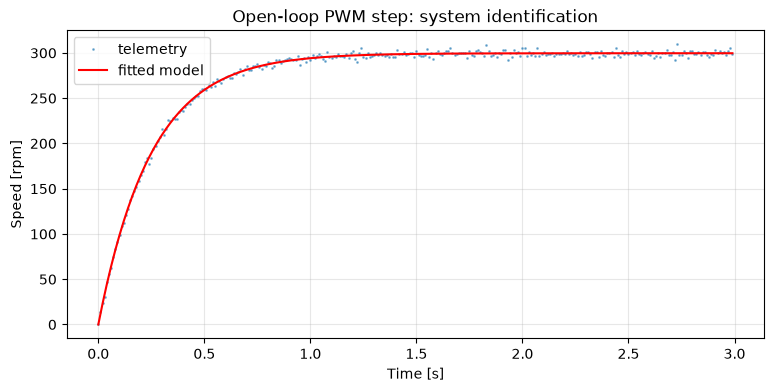

In [2]:
import io
import pandas as pd
from scipy.optimize import curve_fit

# --- 步驟 1:模擬一段「ESP32 開迴路步階」遙測(實機上這段來自序列埠)---
K_true, tau_true = 3.0, 0.25        # 真實馬達:3 rpm / pwm-unit,τ=250 ms
fs_rcp = 100.0                       # ESP32 迴路 100 Hz
dt_rcp = 1 / fs_rcp
n = 300                              # 3 秒
rng = np.random.default_rng(1)
pwm_step = 100.0
t_log = np.arange(n) * dt_rcp
rpm = K_true * pwm_step * (1 - np.exp(-t_log / tau_true)) + rng.normal(0, 3.0, n)

lines = ['millis,target,actual,pwm']
for k in range(n):
    lines.append(f'{int(t_log[k]*1000)},0.0,{rpm[k]:.3f},{pwm_step:.1f}')
telemetry = '\n'.join(lines)
print('遙測前 5 行:')
print('\n'.join(telemetry.splitlines()[:5]))

# --- 步驟 2:解析 + 擬合 ---
df = pd.read_csv(io.StringIO(telemetry))
df['t'] = df['millis'] / 1000.0

def first_order_step(t, K, tau):
    return K * pwm_step * (1 - np.exp(-t / tau))

(K_fit, tau_fit), _ = curve_fit(first_order_step, df['t'], df['actual'], p0=[1.0, 0.1])
print(f'\n擬合:K={K_fit:.3f}(真值 {K_true}),tau={tau_fit*1000:.1f} ms(真值 {tau_true*1000:.0f} ms)')

plt.figure(figsize=(9, 4))
plt.plot(df['t'], df['actual'], '.', ms=2, alpha=0.5, label='telemetry')
plt.plot(df['t'], first_order_step(df['t'], K_fit, tau_fit), 'r-', label='fitted model')
plt.xlabel('Time [s]'); plt.ylabel('Speed [rpm]'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Open-loop PWM step: system identification')
plt.show()

## 步驟 3–4:λ-tuning 設計 PI,先模擬驗證

一階受控體的 λ-tuning(IMC):$k_p = \dfrac{\tau}{K\lambda}$、$k_i = k_p/\tau$,
λ = 期望閉迴路時間常數(取 100 ms,約為 τ/2.5)。

λ-tuning:kp=0.8341 pwm/rpm,ki=3.3373


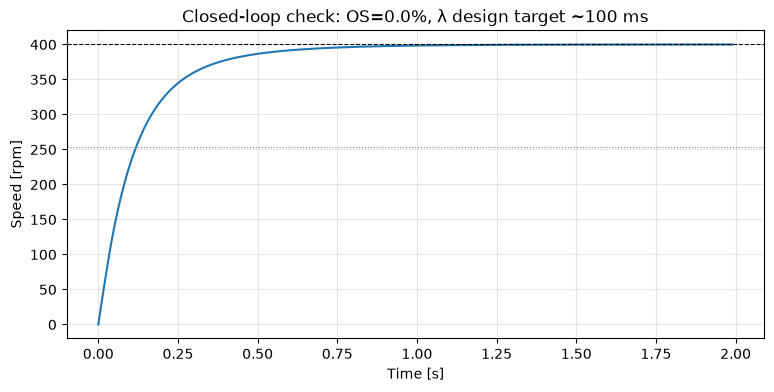

閉迴路指標: {'rise_time': 0.28, 'overshoot_pct': 0.0, 'settling_time': 0.61, 'steady_state_error': 0.0267}


In [3]:
lam = 0.10
kp_rcp = tau_fit / (K_fit * lam)
ki_rcp = kp_rcp / tau_fit
print(f'λ-tuning:kp={kp_rcp:.4f} pwm/rpm,ki={ki_rcp:.4f}')

# 用「真實」受控體(擬合時不知道的)做離散閉迴路驗證,100 Hz、PWM 飽和 ±255
n2 = int(2.0 / dt_rcp)
t2 = np.arange(n2) * dt_rcp
target = 400.0
ctrl = DiscretePID(kp_rcp, ki_rcp, dt=dt_rcp, out_min=-255, out_max=255)
y_rpm = np.empty(n2)
y_state = 0.0
for k in range(n2):
    y_rpm[k] = y_state
    u = ctrl.step(target - y_state)
    y_state += (K_true * u - y_state) / tau_true * dt_rcp   # 真實一階馬達

mets = step_metrics(t2, y_rpm, target=target)
plt.figure(figsize=(9, 4))
plt.plot(t2, y_rpm); plt.axhline(target, color='k', ls='--', lw=0.8)
plt.axhline(target * (1 - np.exp(-1)), color='gray', ls=':', lw=0.8)
plt.xlabel('Time [s]'); plt.ylabel('Speed [rpm]'); plt.grid(alpha=0.3)
plt.title(f'Closed-loop check: OS={mets["overshoot_pct"]:.1f}%, λ design target ~{lam*1000:.0f} ms')
plt.show()
print('閉迴路指標:', {k: round(v, 4) for k, v in mets.items()})

## 步驟 5:韌體等價性驗證

韌體 PID(見 `hardware/esp32/src/pid.h`)的差分方程與 `DiscretePID` 有一處已知差異:
韌體**先積分再算輸出**,`DiscretePID` 先算輸出再積分 —— 差一拍積分量 $k_i e T_s$。
下面逐樣本比對,確認差異就只有這一項(host 端 C++ 編譯比對見 `hardware/esp32/test_host/`)。

In [4]:
class CStylePID:
    """逐行翻譯韌體 pid.h 的 pid_step():integ 先更新,導數不濾波。"""
    def __init__(self, kp, ki, kd, dt, out_min, out_max):
        self.kp, self.ki, self.kd, self.dt = kp, ki, kd, dt
        self.out_min, self.out_max = out_min, out_max
        self.integ, self.prev_e, self.first = 0.0, 0.0, True
    def step(self, e):
        self.integ += e * self.dt
        d = 0.0 if self.first else (e - self.prev_e) / self.dt
        self.first = False
        self.prev_e = e
        u = self.kp * e + self.ki * self.integ + self.kd * d
        return min(max(u, self.out_min), self.out_max)

rng = np.random.default_rng(3)
e_seq = rng.normal(0, 50, 500)                    # 隨機誤差序列 [rpm]
c_fw = CStylePID(kp_rcp, ki_rcp, 0.0, dt_rcp, -255, 255)
c_py = DiscretePID(kp_rcp, ki_rcp, 0.0, dt=dt_rcp, out_min=-255, out_max=255,
                   anti_windup=False)
u_fw = np.array([c_fw.step(e) for e in e_seq])
u_py = np.array([c_py.step(e) for e in e_seq])
diff = np.abs(u_fw - u_py)
bound = ki_rcp * np.abs(e_seq) * dt_rcp           # 理論差異上限:一拍積分量
print(f'最大差異 {diff.max():.4f} pwm-unit;理論上限 max(ki·|e|·Ts) = {bound.max():.4f}')
print(f'超出理論上限的樣本數:{(diff > bound + 1e-9).sum()} / {len(e_seq)}')

最大差異 5.5450 pwm-unit;理論上限 max(ki·|e|·Ts) = 5.5450
超出理論上限的樣本數:0 / 500


In [5]:
# ✅ 驗證
assert abs(K_fit - K_true) / K_true < 0.05          # 辨識 K 誤差 < 5%
assert abs(tau_fit - tau_true) / tau_true < 0.10    # 辨識 tau 誤差 < 10%
assert mets['overshoot_pct'] < 15                   # λ-tuning 閉迴路溫和
assert abs(mets['steady_state_error']) < 5          # 穩態到位(rpm)
i63 = np.nonzero(y_rpm >= target * 0.632)[0][0]
assert abs(t2[i63] - lam) / lam < 0.5               # 63% 時間 ≈ λ
assert np.all(diff <= bound + 1e-9)                 # 韌體/Python 差異全在理論上限內
print('Ch19 驗證通過 ✅')

Ch19 驗證通過 ✅


## 上實機(硬體到位後)

```bash
cd ../../hardware/esp32
pio run -t upload && pio device monitor        # 燒錄 + 看遙測
```
1. `STEP,100` 記錄開迴路步階 → 用本 notebook 步驟 2 擬合你的馬達。
2. 把算出的 kp/ki 用 `SET,KP,…`/`SET,KI,…` 下發,`SET,TARGET,400` 看階躍。
3. 用第 2 章的 DSA:把 chirp 疊加在 target 上,量實機閉迴路 FRF。

## 練習
1. 把 λ 掃 0.05/0.1/0.2,模擬三條 step response —— λ 就是「你想要多快」的旋鈕。
2. 對擬合殘差畫直方圖,雜訊是白的嗎?如果不是,漏掉了什麼動態?
3. 在模擬加入 20 ms 的傳輸延遲(序列埠+排程),λ=0.05 還穩嗎?對照第 4 章。
4. 讀 `hardware/esp32/src/pid.h`,找出它與 `DiscretePID` 的第二個差異(提示:導數濾波)。